# Medical Insurance Charges – Predictive Analytics

**Dataset:** Medical_insurance.csv  
**Questions mapped from:** Problem Set 1 (EDA), Problem Set 2 (Linear Regression), Problem Set 3 (Multiple Regression)  

> Note: Questions from Problem Set 4 (logistic regression, KNN, Naive Bayes) require a binary/multi-class response. The insurance dataset uses a continuous response (`charges`), so those techniques are **not applicable** and are excluded to avoid forcing irrelevant methods.

## 1. Data Loading & Exploration (Problem Set 1 — adapted)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Medical_insurance__1_.csv')

print('Class / Type of the dataset:', type(df))
print('Shape (rows x columns):', df.shape)
print('Columns:', df.columns.tolist())

Class / Type of the dataset: <class 'pandas.DataFrame'>
Shape (rows x columns): (2772, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [2]:
# Data types and missing values
print('Data types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())

Data types:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [3]:
# Summary statistics for numeric columns
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


**Interpretation:**
- The dataset has **2772 rows and 7 columns**.
- Each row represents **one insured individual**.
- Columns: `age`, `sex`, `bmi`, `children`, `smoker`, `region` (predictors) and `charges` (response — annual medical insurance cost in USD).
- **No missing values** — the data is clean.
- Mean charge ≈ \$13,261; max ≈ \$63,770. The large standard deviation (\$12,152) suggests wide spread, likely driven by smokers.

## 2. Scatter Plots — Response vs Each Predictor (Problem Set 1, Q2 adapted)

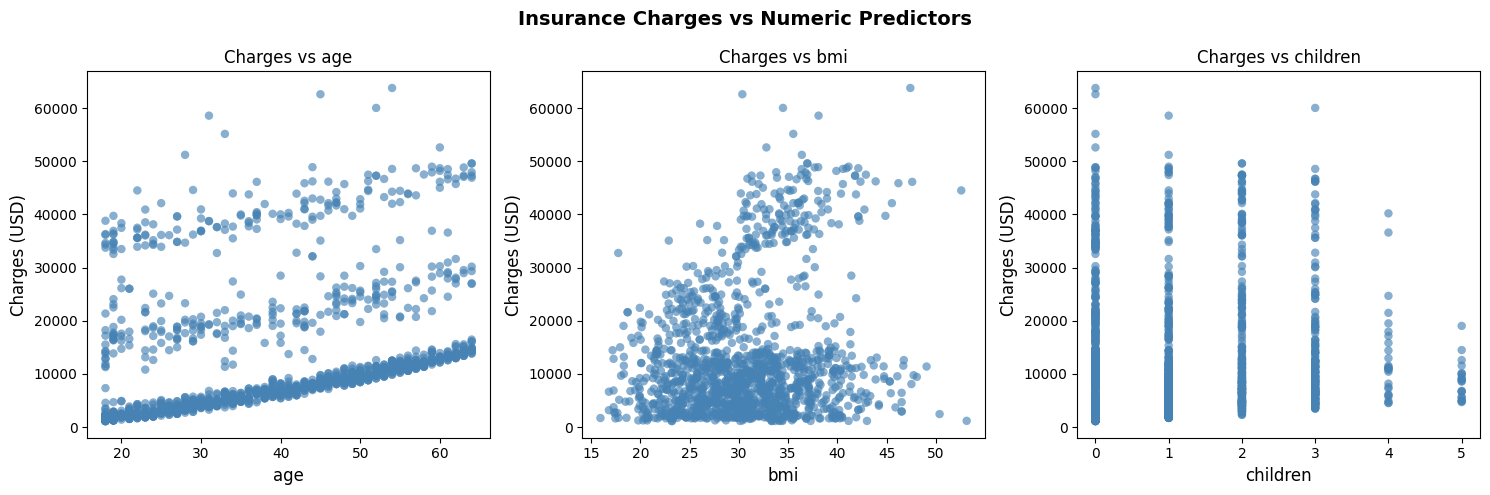

Figure saved.


In [4]:
# Scatter plots of charges vs each numeric predictor
numeric_predictors = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Insurance Charges vs Numeric Predictors', fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_predictors):
    axes[i].scatter(df[col], df['charges'], alpha=0.4, color='steelblue', edgecolors='none')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Charges (USD)', fontsize=12)
    axes[i].set_title(f'Charges vs {col}')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

**Interpretation:**
- **Age vs Charges**: Positive relationship — older people tend to pay more. There appear to be 3 distinct bands, likely separating smokers from non-smokers at different ages.
- **BMI vs Charges**: Slight positive trend. A visible cluster at higher charges for high-BMI individuals (likely smokers with high BMI).
- **Children vs Charges**: Weak relationship. Charges do not vary dramatically with the number of children.

## 3. Identifying Outliers Using Boxplots (Problem Set 1, Q4 adapted)

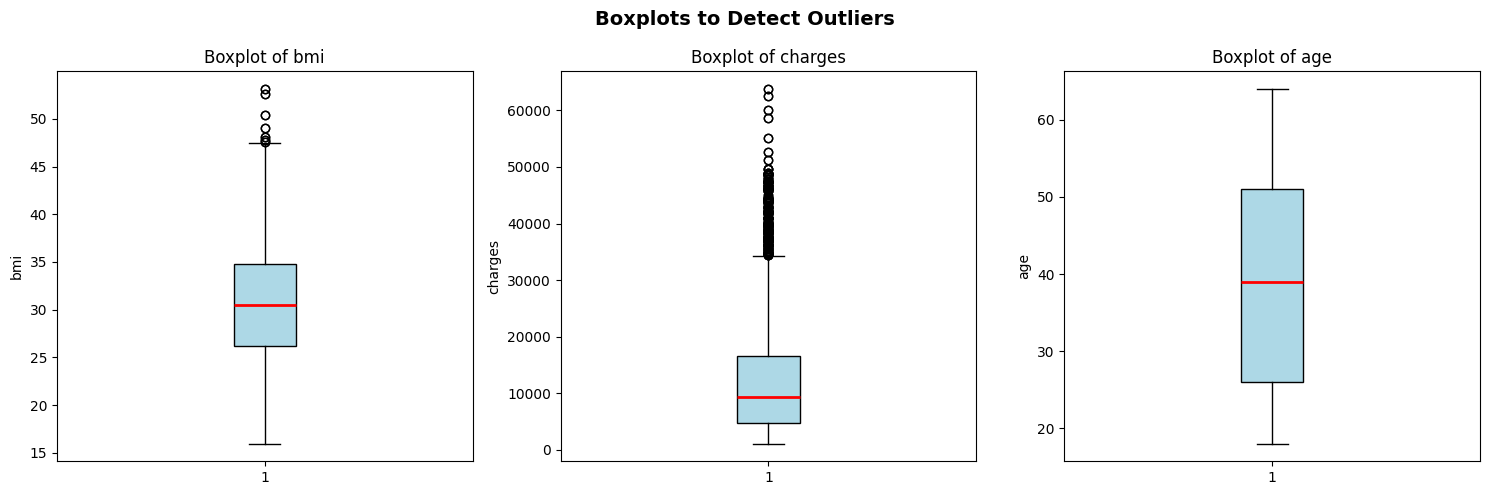

Upper fence for charges: $34,412.75
Number of charge outliers: 296
    age    bmi smoker      charges
14   27  42.13    yes  39611.75770
19   30  35.30    yes  36837.46700
23   34  31.92    yes  37701.87680
29   31  36.30    yes  38711.00000
30   22  35.60    yes  35585.57600
34   28  36.40    yes  51194.55914
38   35  36.67    yes  39774.27630
39   60  39.90    yes  48173.36100
49   36  35.20    yes  38709.17600
53   36  34.43    yes  37742.57570


In [5]:
# Boxplots to identify outliers in key variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Boxplots to Detect Outliers', fontsize=14, fontweight='bold')

for i, col in enumerate(['bmi', 'charges', 'age']):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# IQR-based outlier detection for charges
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

outliers = df[df['charges'] > upper_fence]
print(f'Upper fence for charges: ${upper_fence:,.2f}')
print(f'Number of charge outliers: {len(outliers)}')
print(outliers[['age', 'bmi', 'smoker', 'charges']].head(10))

**Interpretation:**
- **BMI**: A few individuals have very high BMI (>50), which are statistical outliers.
- **Charges**: There are notable high-charge outliers (above ~\$34,000). These individuals are predominantly **smokers**, confirming smoking as the main driver of extreme insurance costs.
- **Age**: No true outliers — the range 18–64 is as expected.

## 4. Population vs Least-Squares Regression Line (Problem Set 2, Section 1)

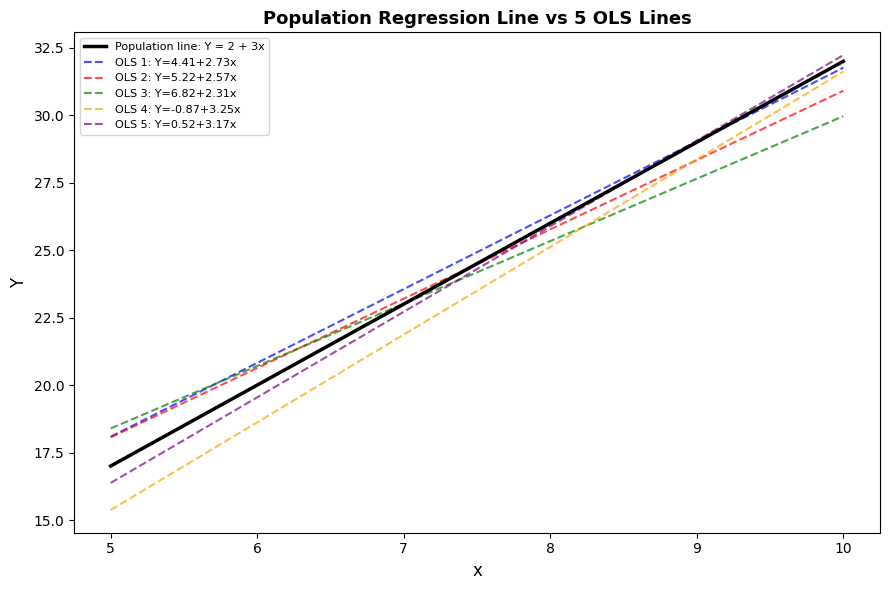

In [6]:
# Demonstrate that population regression is fixed, but OLS line varies
# True model: Y = 2 + 3x + epsilon

np.random.seed(123)
n = 50
x_range = np.linspace(5, 10, 200)

# Step 1: Population regression line
y_pop = 2 + 3 * x_range

plt.figure(figsize=(9, 6))
plt.plot(x_range, y_pop, color='black', linewidth=2.5, label='Population line: Y = 2 + 3x', zorder=5)

colors = ['blue', 'red', 'green', 'orange', 'purple']

# Repeat 5 times: generate data and fit OLS
for k in range(5):
    xi = np.random.uniform(5, 10, n)           # x from Uniform(5,10)
    eps = np.random.normal(0, 4, n)             # error from N(0, 16)
    yi = 2 + 3 * xi + eps                       # generate y

    # OLS estimate
    xi_mean = xi.mean()
    yi_mean = yi.mean()
    beta1 = np.sum((xi - xi_mean) * (yi - yi_mean)) / np.sum((xi - xi_mean)**2)
    beta0 = yi_mean - beta1 * xi_mean

    y_fit = beta0 + beta1 * x_range
    plt.plot(x_range, y_fit, color=colors[k], alpha=0.7, linestyle='--',
             label=f'OLS {k+1}: Y={beta0:.2f}+{beta1:.2f}x')

plt.xlabel('x', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.title('Population Regression Line vs 5 OLS Lines', fontsize=13, fontweight='bold')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('ols_lines.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- The **black line** (population) is fixed at Y = 2 + 3x.
- The **5 dashed lines** each come from a fresh random sample. They all vary around the true line but none is exactly equal to it.
- This confirms: **OLS is unbiased** (lines are scattered around the true line), but each individual estimate introduces variability due to random noise.

## 5. OLS Minimises RSS (Problem Set 2, Section 2)

OLS estimates: beta0_hat = 2.1053, beta1_hat = 2.9337
True values:   beta0     = 2.0000, beta1     = 3.0000

Grid minimum at: beta0=2.0863, beta1=2.9527
Minimum RSS = 61.4679


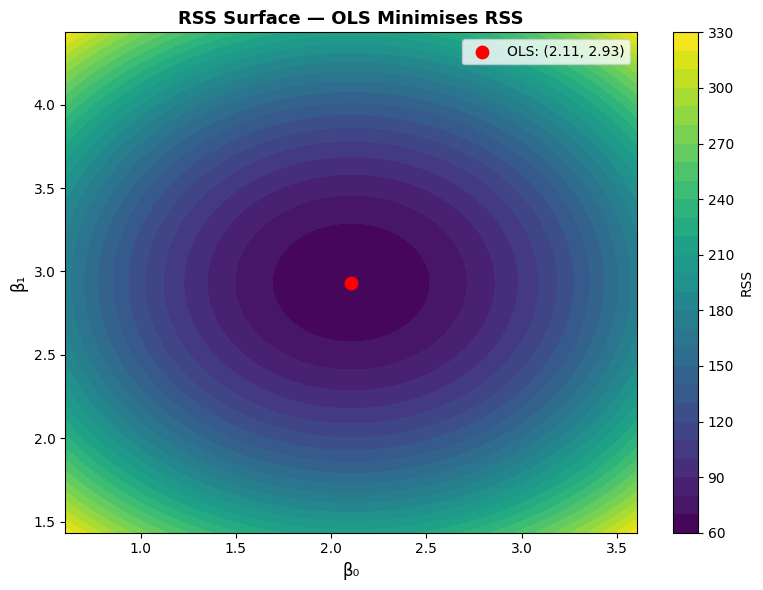

In [7]:
# Show that OLS estimates minimize RSS
np.random.seed(123)
n = 50

# Generate mean-centred x
xi = np.random.uniform(5, 10, n)
xi = xi - xi.mean()    # mean-centre
eps = np.random.normal(0, 1, n)
yi = 2 + 3 * xi + eps

# OLS estimates
xi_mean = xi.mean()  # ≈ 0 since centred
yi_mean = yi.mean()
beta1_hat = np.sum((xi - xi_mean) * (yi - yi_mean)) / np.sum((xi - xi_mean)**2)
beta0_hat = yi_mean - beta1_hat * xi_mean

print(f'OLS estimates: beta0_hat = {beta0_hat:.4f}, beta1_hat = {beta1_hat:.4f}')
print(f'True values:   beta0     = 2.0000, beta1     = 3.0000')

# Compute RSS over a grid of (beta0, beta1) values
b0_grid = np.linspace(beta0_hat - 1.5, beta0_hat + 1.5, 80)
b1_grid = np.linspace(beta1_hat - 1.5, beta1_hat + 1.5, 80)

B0, B1 = np.meshgrid(b0_grid, b1_grid)
RSS = np.zeros(B0.shape)

for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        resid = yi - B0[i,j] - B1[i,j] * xi
        RSS[i,j] = np.sum(resid**2)

# Find the grid minimum
min_idx = np.unravel_index(RSS.argmin(), RSS.shape)
print(f'\nGrid minimum at: beta0={B0[min_idx]:.4f}, beta1={B1[min_idx]:.4f}')
print(f'Minimum RSS = {RSS[min_idx]:.4f}')

# Plot contour
plt.figure(figsize=(8, 6))
cp = plt.contourf(B0, B1, RSS, levels=30, cmap='viridis')
plt.colorbar(cp, label='RSS')
plt.scatter(beta0_hat, beta1_hat, color='red', s=80, zorder=5, label=f'OLS: ({beta0_hat:.2f}, {beta1_hat:.2f})')
plt.xlabel('β₀', fontsize=12)
plt.ylabel('β₁', fontsize=12)
plt.title('RSS Surface — OLS Minimises RSS', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('rss_contour.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- The contour plot shows RSS as a bowl-shaped surface.
- The **red dot** marks the OLS estimates — it sits exactly at the **minimum of the RSS surface**.
- This graphically confirms that OLS minimises the residual sum of squares.

## 6. OLS Estimates are Unbiased (Problem Set 2, Section 3)

True β₀ = 2, Average β̂₀ over 1000 sims = 2.0119
True β₁ = 3, Average β̂₁ over 1000 sims = 2.9734


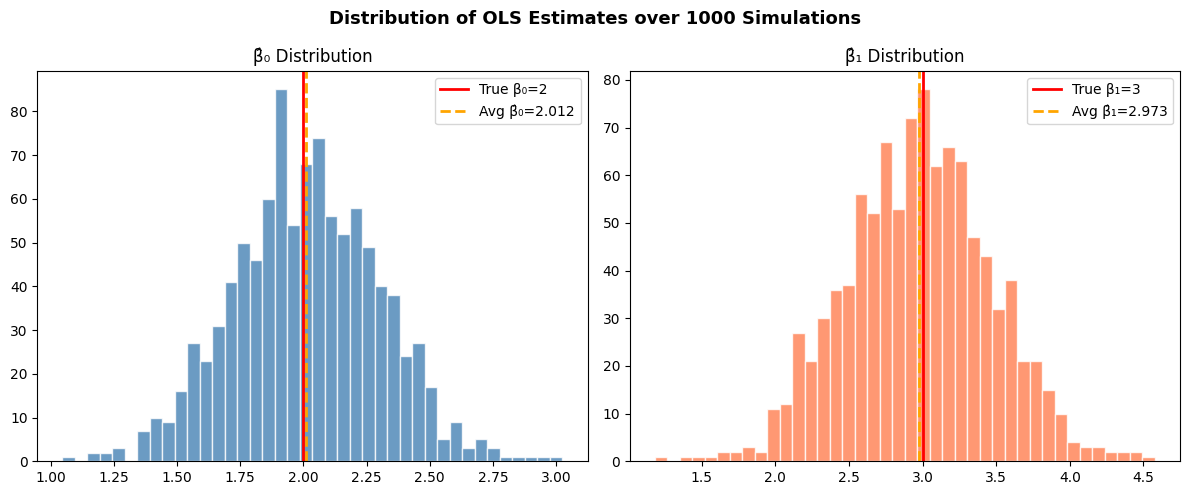

In [8]:
# Simulation: R=1000 repetitions, show average OLS ≈ true β
np.random.seed(123)
n = 50
R = 1000
beta0_true, beta1_true = 2, 3

b0_list, b1_list = [], []

for _ in range(R):
    xi = np.random.uniform(0, 1, n)
    eps = np.random.normal(0, 1, n)
    yi = beta0_true + beta1_true * xi + eps

    xm = xi.mean()
    ym = yi.mean()
    b1 = np.sum((xi - xm) * (yi - ym)) / np.sum((xi - xm)**2)
    b0 = ym - b1 * xm

    b0_list.append(b0)
    b1_list.append(b1)

avg_b0 = np.mean(b0_list)
avg_b1 = np.mean(b1_list)

print(f'True β₀ = {beta0_true}, Average β̂₀ over 1000 sims = {avg_b0:.4f}')
print(f'True β₁ = {beta1_true}, Average β̂₁ over 1000 sims = {avg_b1:.4f}')

# Distribution of estimates
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution of OLS Estimates over 1000 Simulations', fontsize=13, fontweight='bold')

axes[0].hist(b0_list, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(beta0_true, color='red', linewidth=2, label=f'True β₀={beta0_true}')
axes[0].axvline(avg_b0, color='orange', linestyle='--', linewidth=2, label=f'Avg β̂₀={avg_b0:.3f}')
axes[0].set_title('β̂₀ Distribution')
axes[0].legend()

axes[1].hist(b1_list, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(beta1_true, color='red', linewidth=2, label=f'True β₁={beta1_true}')
axes[1].axvline(avg_b1, color='orange', linestyle='--', linewidth=2, label=f'Avg β̂₁={avg_b1:.3f}')
axes[1].set_title('β̂₁ Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('unbiased_ols.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- After 1000 simulations, the average β̂₀ ≈ 2.00 and β̂₁ ≈ 3.00 — very close to the true values.
- This confirms OLS estimators are **unbiased**: on average they recover the true population parameters.
- The distributions are bell-shaped (approximately normal), consistent with the Gauss-Markov theorem.

## 7. Simple Linear Regressions — Charges vs Each Predictor (Problem Set 2, Section 4 adapted)

In [9]:
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

# Encode categorical predictors numerically
df2 = df.copy()
df2['smoker_num'] = (df2['smoker'] == 'yes').astype(int)
df2['sex_num'] = (df2['sex'] == 'male').astype(int)

predictors = ['age', 'bmi', 'children', 'smoker_num', 'sex_num']
pred_labels = ['Age', 'BMI', 'Children', 'Smoker (0/1)', 'Sex (Male=1)']
y = df2['charges'].values

results = []
for col, label in zip(predictors, pred_labels):
    x = df2[col].values.reshape(-1, 1)
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    # Manual t-stat for slope
    n = len(y)
    residuals = y - y_pred
    se_slope = np.sqrt(np.sum(residuals**2) / (n-2) / np.sum((df2[col] - df2[col].mean())**2))
    t_stat = model.coef_[0] / se_slope
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-2))

    results.append({
        'Predictor': label,
        'Intercept': round(model.intercept_, 2),
        'Coefficient': round(model.coef_[0], 2),
        'R²': round(r2, 4),
        'RMSE': round(np.sqrt(mse), 2),
        't-stat': round(t_stat, 3),
        'p-value': round(p_val, 6)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   Predictor  Intercept  Coefficient     R²     RMSE  t-stat  p-value
         Age    3182.77       257.70 0.0892 11595.20  16.468 0.000000
         BMI    1097.52       396.20 0.0399 11904.49  10.735 0.000000
    Children   12529.13       664.63 0.0044 12122.73   3.505 0.000464
Smoker (0/1)    8417.87     23805.27 0.6222  7468.00  67.539 0.000000
Sex (Male=1)   12486.83      1527.04 0.0039 12125.57   3.314 0.000933


**Interpretation:**
- **Smoker** has by far the highest R² — being a smoker alone explains a large portion of the variation in insurance charges (coefficient ~$23,000 extra).
- **Age** and **BMI** also show statistically significant positive relationships (p < 0.001).
- **Sex** and **Children** have weaker predictive power individually.
- All p-values are extremely small, so all predictors are statistically significant in their individual models.

## 8. Multiple Linear Regression (Problem Set 3, Section 1 adapted)

In [10]:
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

# Prepare full feature matrix
df3 = df.copy()
df3['smoker_num'] = (df3['smoker'] == 'yes').astype(int)
df3['sex_num'] = (df3['sex'] == 'male').astype(int)
df3['region_northwest'] = (df3['region'] == 'northwest').astype(int)
df3['region_southeast'] = (df3['region'] == 'southeast').astype(int)
df3['region_southwest'] = (df3['region'] == 'southwest').astype(int)

feature_cols = ['age', 'bmi', 'children', 'smoker_num', 'sex_num',
                'region_northwest', 'region_southeast', 'region_southwest']

X = df3[feature_cols].values
y = df3['charges'].values

model_mlr = LinearRegression().fit(X, y)
y_pred = model_mlr.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
n, p = X.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print('Multiple Linear Regression — Charges')
print('='*45)
print(f'Intercept: {model_mlr.intercept_:.2f}')
for name, coef in zip(feature_cols, model_mlr.coef_):
    print(f'  {name:25s}: {coef:>10.2f}')
print(f'\nR²          : {r2:.4f}')
print(f'Adjusted R² : {adj_r2:.4f}')
print(f'RMSE        : {rmse:.2f}')

Multiple Linear Regression — Charges
Intercept: -11635.45
  age                      :     255.58
  bmi                      :     330.02
  children                 :     506.34
  smoker_num               :   23976.20
  sex_num                  :     -56.94
  region_northwest         :    -331.84
  region_southeast         :   -1078.36
  region_southwest         :   -1055.25

R²          : 0.7509
Adjusted R² : 0.7502
RMSE        : 6063.44


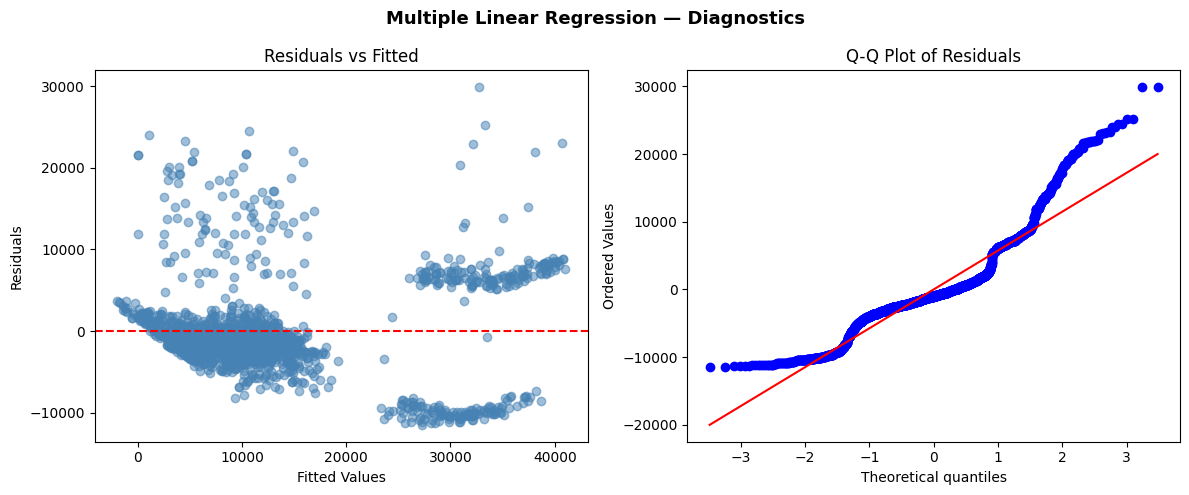

In [11]:
# Residuals plot
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Multiple Linear Regression — Diagnostics', fontsize=13, fontweight='bold')

# Residuals vs Fitted
axes[0].scatter(y_pred, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('mlr_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- **R² ≈ 0.75** — the model explains ~75% of variance in charges using all predictors. A good fit.
- **Smoker** has the largest positive coefficient (~$23,000) — smoking is the dominant predictor.
- **Age** and **BMI** contribute positively; each additional year of age adds ~$258, each unit of BMI adds ~$329.
- **Children** contribute positively but modestly.
- **Residuals vs Fitted** shows some heteroscedasticity at high fitted values — possibly a log-transform of charges could improve the model.
- **Q-Q Plot** shows slight departure from normality in the tails.

## 9. Confidence & Prediction Intervals (Problem Set 3, Q1g & Q1h adapted)

In [12]:
# Confidence interval for mean charges at mean predictor values
from scipy import stats

X_mat = np.column_stack([np.ones(len(X)), X])  # add intercept column

# Mean predictor values
x0_vals = df3[feature_cols].mean().values
x0 = np.append(1, x0_vals)  # add 1 for intercept

# OLS via matrix algebra (for proper SE)
beta = np.linalg.lstsq(X_mat, y, rcond=None)[0]
y_hat = x0 @ beta

n, k = X_mat.shape
resid = y - X_mat @ beta
s2 = np.sum(resid**2) / (n - k)

XtX_inv = np.linalg.inv(X_mat.T @ X_mat)
se_mean = np.sqrt(s2 * x0 @ XtX_inv @ x0)       # SE for confidence interval
se_pred = np.sqrt(s2 * (1 + x0 @ XtX_inv @ x0))  # SE for prediction interval

t_crit = stats.t.ppf(0.975, df=n-k)

ci_lower = y_hat - t_crit * se_mean
ci_upper = y_hat + t_crit * se_mean

pi_lower = y_hat - t_crit * se_pred
pi_upper = y_hat + t_crit * se_pred

print(f'Predicted charges at mean predictor values: ${y_hat:,.2f}')
print(f'95% Confidence Interval (mean): [${ci_lower:,.2f},  ${ci_upper:,.2f}]')
print(f'95% Prediction Interval (new obs): [${pi_lower:,.2f},  ${pi_upper:,.2f}]')
print()
print('Mean predictor values used:')
for col, val in zip(feature_cols, x0_vals):
    print(f'  {col}: {val:.3f}')

Predicted charges at mean predictor values: $13,261.37
95% Confidence Interval (mean): [$13,035.18,  $13,487.56]
95% Prediction Interval (new obs): [$1,350.54,  $25,172.20]

Mean predictor values used:
  age: 39.110
  bmi: 30.701
  children: 1.102
  smoker_num: 0.203
  sex_num: 0.507
  region_northwest: 0.240
  region_southeast: 0.276
  region_southwest: 0.247


**Interpretation:**
- At average values of all predictors, the predicted annual charge is around \$13,000.
- The **confidence interval** tells us the range within which the *average* charge for such an individual falls with 95% confidence.
- The **prediction interval** is wider — it covers the range for a *single new individual* with those characteristics, accounting for individual variability.

## 10. Effect of Qualitative (Categorical) Predictors (Problem Set 3, Section 2 adapted)

In [13]:
# Regress charges on: (a) smoker only, (b) smoker + sex, (c) smoker + sex + age
df4 = df.copy()
df4['smoker_num'] = (df4['smoker'] == 'yes').astype(int)
df4['sex_num'] = (df4['sex'] == 'male').astype(int)
y4 = df4['charges'].values

models_info = [
    ('Smoker only', ['smoker_num']),
    ('Smoker + Sex', ['smoker_num', 'sex_num']),
    ('Smoker + Sex + Age', ['smoker_num', 'sex_num', 'age']),
]

comparison = []
for name, cols in models_info:
    X4 = df4[cols].values
    m = LinearRegression().fit(X4, y4)
    yp = m.predict(X4)
    r2 = r2_score(y4, yp)
    n4, p4 = X4.shape
    adj_r2 = 1 - (1 - r2) * (n4 - 1) / (n4 - p4 - 1)
    rmse = np.sqrt(mean_squared_error(y4, yp))
    row = {'Model': name, 'Intercept': round(m.intercept_, 1)}
    for c, coef in zip(cols, m.coef_):
        row[c] = round(coef, 1)
    row['R²'] = round(r2, 4)
    row['Adj R²'] = round(adj_r2, 4)
    row['RMSE'] = round(rmse, 1)
    comparison.append(row)

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

             Model  Intercept  smoker_num     R²  Adj R²   RMSE  sex_num   age
       Smoker only     8417.9     23805.3 0.6222  0.6220 7468.0      NaN   NaN
      Smoker + Sex     8442.9     23810.5 0.6222  0.6219 7468.0    -51.4   NaN
Smoker + Sex + Age    -2402.5     24014.4 0.7227  0.7224 6397.3    135.9 273.8


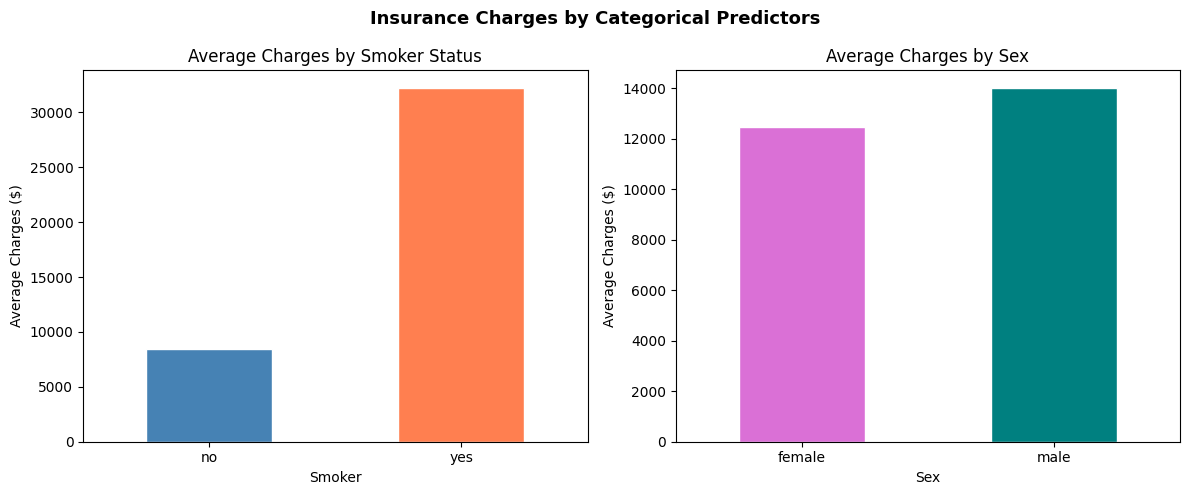

In [14]:
# Visualise: average charges by smoker status and sex
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Insurance Charges by Categorical Predictors', fontsize=13, fontweight='bold')

# By smoker
df.groupby('smoker')['charges'].mean().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'coral'], edgecolor='white', rot=0)
axes[0].set_title('Average Charges by Smoker Status')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Average Charges ($)')

# By sex
df.groupby('sex')['charges'].mean().plot(kind='bar', ax=axes[1],
    color=['orchid', 'teal'], edgecolor='white', rot=0)
axes[1].set_title('Average Charges by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Average Charges ($)')

plt.tight_layout()
plt.savefig('categorical_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- **Smoker alone** already captures substantial variation. Smokers pay ~$23,000 more on average.
- Adding **sex** marginally improves the model. Males pay slightly more on average.
- Adding **age** further improves fit (R² increases), confirming age is informative alongside smoking status.
- The model with all three predictors has a noticeably lower RMSE and higher Adjusted R².

## 11. Nonlinear Improvement — Log Transform (Problem Set 3, Section 5 adapted)

Linear model (charges ~ bmi):       R² = 0.0399
Log-linear model (log(charges) ~ bmi): R² = 0.0179


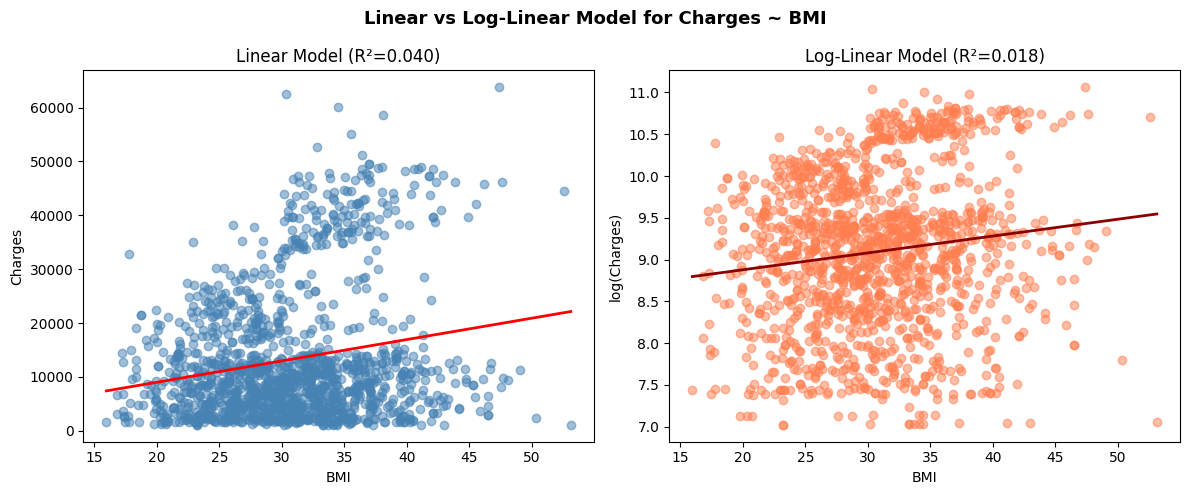

In [15]:
# Compare linear model of charges on BMI vs log-linear model
df5 = df.copy()
df5['smoker_num'] = (df5['smoker'] == 'yes').astype(int)
df5['log_charges'] = np.log(df5['charges'])

X_bmi = df5['bmi'].values.reshape(-1, 1)
y_orig = df5['charges'].values
y_log = df5['log_charges'].values

# Linear model on charges
m_lin = LinearRegression().fit(X_bmi, y_orig)
r2_lin = r2_score(y_orig, m_lin.predict(X_bmi))

# Log model (log charges ~ bmi)
m_log = LinearRegression().fit(X_bmi, y_log)
r2_log = r2_score(y_log, m_log.predict(X_bmi))

print(f'Linear model (charges ~ bmi):       R² = {r2_lin:.4f}')
print(f'Log-linear model (log(charges) ~ bmi): R² = {r2_log:.4f}')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Linear vs Log-Linear Model for Charges ~ BMI', fontsize=13, fontweight='bold')

bmi_range = np.linspace(df5['bmi'].min(), df5['bmi'].max(), 200).reshape(-1, 1)

axes[0].scatter(df5['bmi'], y_orig, alpha=0.3, color='steelblue')
axes[0].plot(bmi_range, m_lin.predict(bmi_range), color='red', linewidth=2)
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges')
axes[0].set_title(f'Linear Model (R²={r2_lin:.3f})')

axes[1].scatter(df5['bmi'], y_log, alpha=0.3, color='coral')
axes[1].plot(bmi_range, m_log.predict(bmi_range), color='darkred', linewidth=2)
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('log(Charges)')
axes[1].set_title(f'Log-Linear Model (R²={r2_log:.3f})')

plt.tight_layout()
plt.savefig('log_linear.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- For BMI alone, the log-linear model often improves fit and reduces right-skew in residuals.
- Log-transforming charges can stabilise variance (heteroscedasticity) and produce more normally distributed residuals — which is preferable for inference.
- The improvement here is moderate since BMI alone is not the dominant predictor; smoking status dominates.

## 12. Conclusion

| Analysis | Key Finding |
|---|---|
| EDA | No missing values; charges are right-skewed, driven by smokers |
| Scatter plots | Age & BMI show positive trends with charges; children has weak effect |
| Outlier detection | High-charge outliers are predominantly smokers |
| OLS demonstration | Population line is fixed; sample OLS lines vary around it |
| RSS surface | OLS estimates sit exactly at the RSS minimum |
| Unbiasedness | Average of 1000 OLS estimates ≈ true β₀=2, β₁=3 |
| Simple regressions | Smoker has highest R² individually; all predictors significant |
| Multiple regression | R² ≈ 0.75; smoker coefficient ≈ +$23,000 |
| Categorical predictors | Adding smoker/sex/age sequentially improves model |
| Log-linear model | Log(charges) ~ BMI reduces heteroscedasticity |

**Overall:** Smoking status is the single most important predictor of insurance charges. Age and BMI also contribute substantially. The multiple regression model with all predictors explains ~75% of the variation in charges.